<a href="https://colab.research.google.com/github/Anastasia-Pom/Machine-learning-2026/blob/main/%D0%9B%D0%A06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import f1_score, classification_report
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import accuracy_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
drive_file_path = "/content/drive/MyDrive/synthetic_coffee_health_10000.csv"
df = pd.read_csv("/content/drive/MyDrive/synthetic_coffee_health_10000.csv")

df.head()

Mounted at /content/drive


,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,No,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,No,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [ ]:
target_map = {'Poor':1, 'Fair':2, 'Good':3, 'Excellent':4}
df['Sleep_Quality_codes'] = df['Sleep_Quality'].map(target_map)

X=df
y = df['Sleep_Quality_codes']

print(X.shape)
print(y.value_counts())

(10000, 18)
Sleep_Quality_codes
3    5637
2    2050
4    1352
1     961
Name: count, dtype: int64


In [ ]:
X_train.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption,occupation_codes,Sleep_Quality_codes
4421,4422,21,Female,Canada,2.0,187.1,5.3,Fair,19.6,60,Medium,2.4,Mild,Office,1,0,4,2
9389,9390,44,Female,Mexico,3.6,345.0,7.7,Good,24.8,70,Low,3.1,No,Other,1,1,1,3
7418,7419,34,Male,Mexico,3.0,283.6,6.2,Good,29.1,82,Low,8.4,No,Healthcare,0,1,5,3
5224,5225,70,Female,Brazil,1.4,135.0,8.7,Excellent,20.4,67,Low,9.0,Mild,Healthcare,1,0,5,4
4033,4034,18,Male,Germany,2.5,236.0,7.8,Good,16.7,83,Low,1.3,No,Office,0,1,4,3


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (8000, 18)
Тестовая выборка: (2000, 18)


In [ ]:
numeric_features = ['ID', 'Age', 'Coffee_Intake', 'Caffeine_mg','Sleep_Hours','BMI', 'Heart_Rate','Physical_Activity_Hours','Smoking','Alcohol_Consumption' ]
categorial_features = ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level', 'Health_Issues', 'Occupation']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorial_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorial_transformer, categorial_features)
])

In [ ]:
stacking_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', StackingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=2000, random_state=42)),
            ('rf', RandomForestClassifier(n_estimators=150, random_state=42)),
            ('knn', KNeighborsClassifier(n_neighbors=5))
        ],
        final_estimator=LogisticRegression(max_iter=2000, random_state=42),
        cv=5,
        n_jobs=-1
    ))
])

In [ ]:
percepr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
stacking_model.fit(X_train, y_train)
percepr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['ID', 'Age', 'Coffee_Intake',
                                                   'Caffeine_mg', 'Sleep_Hours',
                                                   'BMI', 'Heart_Rate',
                                                   'Physical_Activity_Hours',
                                                   'Smoking',
                                                   'Alcohol_Consumption']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Gender', 'Country',
                                                   'Sleep_Quality',
                                                   'Stress_Level',
                                                   'Health_Issues',
                                                   'Occupation'])])),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000,
                               random_state=42))])

In [ ]:
y_pred_stacking = stacking_model.predict(X_test)
y_pred_mlp = percepr_model.predict(X_test)

results = pd.DataFrame({
    'Модель': ['Stacking', 'Perceptron'],
    'F1-macro': [
        f1_score(y_test, y_pred_stacking, average='macro'),
        f1_score(y_test, y_pred_mlp, average='macro')
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_stacking),
        mean_absolute_error(y_test, y_pred_mlp)
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_stacking),
        accuracy_score(y_test, y_pred_mlp)
    ]
})

results = results.sort_values(by='F1-macro', ascending=False).reset_index(drop=True)
print(results)

       Модель  F1-macro   MAE  Accuracy
0    Stacking  1.000000  0.00     1.000
1  Perceptron  0.554712  0.35     0.733


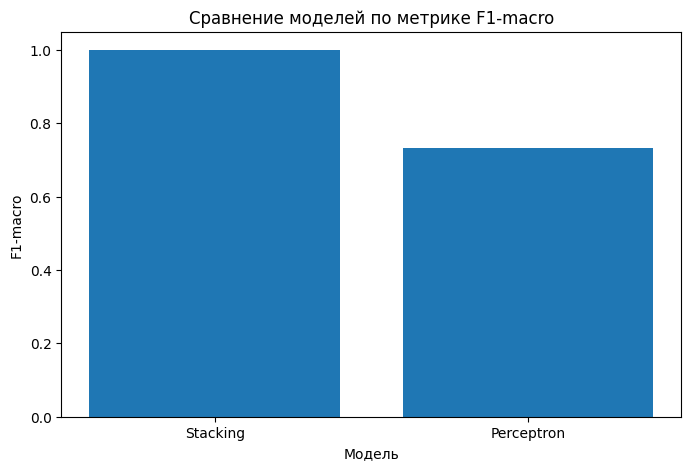

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results['Модель'], results['Accuracy'])
plt.title('Сравнение моделей по метрике F1-macro')
plt.xlabel('Модель')
plt.ylabel('F1-macro')
plt.show()

In [ ]:
!pip install wheel --upgrade

In [ ]:
!pip install gmdhpy

In [ ]:
from gmdhpy import gmdh

In [ ]:
X=df
y = df['Sleep_Hours']

print(X.shape)
print(y.value_counts())

NameError: name 'df' is not defined

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (8000, 18)
Тестовая выборка: (2000, 18)


In [ ]:
model = gmdh.Regressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
result = mean_absolute_error(y_test, y_pred)
print(model)
print('MAE={}'.format(result))

AttributeError: module 'gmdhpy.gmdh' has no attribute 'Regressor'